In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
train_path = r"C:\Users\Apex-pc\Downloads\skin-cancer-detection-ai\train"
test_path = r"C:\Users\Apex-pc\Downloads\skin-cancer-detection-ai\test"

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.


In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,610 (18.42 MB)

 Trainable params: 4,828,610 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 77s 909ms/step - accuracy: 0.6443 - loss: 0.6407 - val_accuracy: 0.5606 - val_loss: 0.7374
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 548ms/step - accuracy: 0.7615 - loss: 0.4772 - val_accuracy: 0.7667 - val_loss: 0.4231
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 552ms/step - accuracy: 0.7831 - loss: 0.4434 - val_accuracy: 0.8000 - val_loss: 0.3998
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 570ms/step - accuracy: 0.7854 - loss: 0.4230 - val_accuracy: 0.7667 - val_loss: 0.4317
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 553ms/step - accuracy: 0.7967 - loss: 0.4165 - val_accuracy: 0.8091 - val_loss: 0.3776
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 556ms/step - accuracy: 0.7956 - loss: 0.4144 - val_accuracy: 0.8364 - val_loss: 0.3648
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 562ms/step - accuracy: 0.8138 - loss: 0.3953 - val_accuracy: 0.8045 - val_loss: 0.3608
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 552ms/step - accuracy: 0.8127 - loss: 0.3790 - val_accu

In [12]:
model.save("skin_cancer_model.h5")

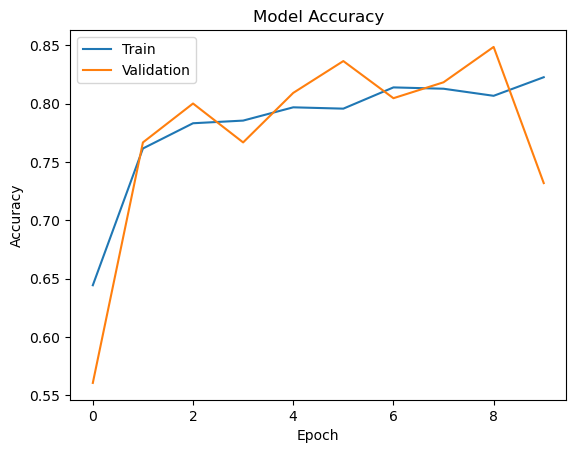

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [14]:
model.save("skin_cancer_model.h5")